In [ ]:
import math
import random
import copy
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
np.random.seed(42)

In [ ]:
class JobShopEnv:
    def __init__(self, jobs_data):
        self.jobs_data = jobs_data
        self.num_jobs = len(jobs_data)
        self.num_machines = max(machine for job in jobs_data for machine, _ in job) + 1
        self.reset()

    def reset(self):
        self.machine_available_time = [0] * self.num_machines
        self.job_available_time = [0] * self.num_jobs
        self.job_progress = [0] * self.num_jobs
        self.schedule = []
        return self

    def clone(self):
        new_env = JobShopEnv(self.jobs_data)
        new_env.machine_available_time = self.machine_available_time.copy()
        new_env.job_available_time = self.job_available_time.copy()
        new_env.job_progress = self.job_progress.copy()
        new_env.schedule = self.schedule.copy()
        return new_env

    def get_legal_actions(self):
        return [job_id for job_id in range(self.num_jobs)
                if self.job_progress[job_id] < len(self.jobs_data[job_id])]

    def is_terminal(self):
        return len(self.get_legal_actions()) == 0

    def step(self, job_id):
        op_idx = self.job_progress[job_id]
        machine_id, duration = self.jobs_data[job_id][op_idx]

        start_time = max(self.machine_available_time[machine_id], self.job_available_time[job_id])
        end_time = start_time + duration

        self.machine_available_time[machine_id] = end_time
        self.job_available_time[job_id] = end_time
        self.job_progress[job_id] += 1

        self.schedule.append((job_id, machine_id, start_time, end_time))
        return self

    def get_makespan(self):
        return max(self.machine_available_time)

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action
        self.children = []
        self.untried_actions = state.get_legal_actions()
        self.visits = 0
        self.score_sum = 0.0

    def uct_select_child(self, exploration_weight=math.sqrt(2)):
        # Balances exploiting known fast schedules vs exploring new sequences
        return max(
            self.children,
            key=lambda c: (c.score_sum / c.visits) + exploration_weight * math.sqrt(math.log(self.visits) / c.visits)
        )

    def expand(self):
        action = self.untried_actions.pop()
        next_state = self.state.clone().step(action)
        child = MCTSNode(state=next_state, parent=self, action=action)
        self.children.append(child)
        return child

    # def simulate(self):
    #     # Rollout randomly to the end of the factory day
    #     current_state = self.state.clone()
    #     while not current_state.is_terminal():
    #         valid_actions = current_state.get_legal_actions()
    #         action = random.choice(valid_actions)
    #         current_state.step(action)

    #     makespan = current_state.get_makespan()
    #     # Reward function: Lower makespan = Higher reward.
    #     # Using 1000 as a scaling constant.
    #     return 1000.0 / makespan

    def simulate(self):
      current_state = self.state.clone()
      while not current_state.is_terminal():
          valid_actions = current_state.get_legal_actions()

          if random.random() < 0.8:
              action = max(valid_actions, key=lambda j: sum(op[1] for op in self.state.jobs_data[j][self.state.job_progress[j]:]))
          else:
              action = random.choice(valid_actions)

          current_state.step(action)

      return 1000.0 / current_state.get_makespan()

    def backpropagate(self, reward):
        self.visits += 1
        self.score_sum += reward
        if self.parent:
            self.parent.backpropagate(reward)

In [ ]:
def run_mcts(root_state, iterations=2000):
    root = MCTSNode(state=root_state)

    for _ in range(iterations):
        node = root

        # Selection
        while not node.untried_actions and node.children:
            node = node.uct_select_child()

        # Expansion
        if node.untried_actions:
            node = node.expand()

        # Simulation
        reward = node.simulate()

        # Backpropagation
        node.backpropagate(reward)

    best_child = max(root.children, key=lambda c: c.visits)
    return best_child.action

Problem Instance 3 Jobs, 3 Machines

In [ ]:
# Format: Job = [(Machine, Duration), (Machine, Duration), ...]
jobs_data = [
    [(0, 3), (1, 2), (2, 2)], # Job 0
    [(0, 2), (2, 1), (1, 4)], # Job 1
    [(1, 4), (2, 3)]          # Job 2
]

print("Running Random Baseline")
random_env = JobShopEnv(jobs_data)
while not random_env.is_terminal():
    action = random.choice(random_env.get_legal_actions())
    random_env.step(action)
print(f"Random Schedule Makespan: {random_env.get_makespan()} units")

print("\nRunning MCTS Optimizer")
mcts_env = JobShopEnv(jobs_data)
while not mcts_env.is_terminal():
    # Run MCTS from the current state to find the best next job to schedule
    best_action = run_mcts(mcts_env.clone(), iterations=1000)
    mcts_env.step(best_action)
    print(f"Scheduled Job {best_action}")

final_makespan = mcts_env.get_makespan()
print(f"\nMCTS Optimized Makespan: {final_makespan} units")

--- Running Random Baseline ---
Random Schedule Makespan: 14 units

--- Running MCTS Optimizer ---
Scheduled Job 2
Scheduled Job 1
Scheduled Job 1
Scheduled Job 2
Scheduled Job 0
Scheduled Job 0
Scheduled Job 1
Scheduled Job 0

MCTS Optimized Makespan: 11 units


/tmp/ipykernel_4883/3343777465.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


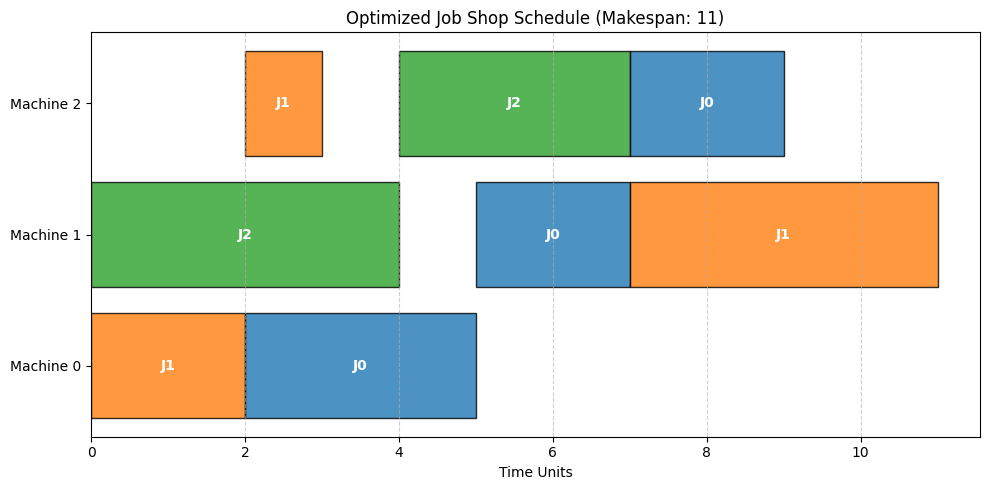

In [ ]:
def plot_gantt_chart(schedule, num_machines, makespan):
    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.get_cmap('tab10')
    job_colors = {}

    for (job_id, machine_id, start_time, end_time) in schedule:
        if job_id not in job_colors:
            job_colors[job_id] = cmap(job_id % 10)

        duration = end_time - start_time
        ax.barh(machine_id, duration, left=start_time, color=job_colors[job_id], edgecolor='black', alpha=0.8)

        ax.text(start_time + duration/2, machine_id, f'J{job_id}',
                ha='center', va='center', color='white', fontweight='bold')

    ax.set_yticks(range(num_machines))
    ax.set_yticklabels([f'Machine {m}' for m in range(num_machines)])
    ax.set_xlabel('Time Units')
    ax.set_title(f'Optimized Job Shop Schedule (Makespan: {makespan})')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_gantt_chart(mcts_env.schedule, mcts_env.num_machines, final_makespan)